In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00


## Descargar y uso de un modelo word2vec

En la siguiente celda vamos a cargar un modelo preentrenado. Este modelo ha sido entrenado con el dataset [word2vec-google-news-300](https://huggingface.co/fse/word2vec-google-news-300). Este dataset está formado por noticias de Google con alrededor de 100 mil millones de palabras, y utilizando embeddings de 300 dimensiones.

NOTA: el modelo es bastante pesado (más de un 1,6 Gb) y puede tardar varios minutos en cargar.

In [4]:
import gensim.downloader as api

wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


La variable *wv* es una especie de diccionario donde las claves son las palabras y los valores sus embeddings. Así, podríamos acceder al embedding de la palabra *perro* como se muestra a continuación. Podemos ver como, efectivamente, el embedding consta de 300 valores numéricos.

In [5]:
# Solo mostramos los primeros 30 valores para no ocupar toda la pantalla
wv['dog'][:30]

array([ 0.05126953, -0.02233887, -0.17285156,  0.16113281, -0.08447266,
        0.05737305,  0.05859375, -0.08251953, -0.01538086, -0.06347656,
        0.1796875 , -0.42382812, -0.02258301, -0.16601562, -0.02514648,
        0.10742188, -0.19921875,  0.15917969, -0.1875    , -0.12011719,
        0.15527344, -0.09912109,  0.14257812, -0.1640625 , -0.08935547,
        0.20019531, -0.14941406,  0.3203125 ,  0.328125  ,  0.02441406],
      dtype=float32)

In [6]:
wv['dog'].shape

(300,)

## Métricas de similitud: la distancia coseno

Para medir la similitud entre vectores de alta dimensionalidad, como es el caso, se suele utilizar la distancia coseno, que se define como uno menos el coseno del ángulo que forman dichos vectores. Además, siempre va a ser una distancia entre 0 - máxima similitud - y 1 - mínima similitud.

```
cos_dist(u,v) = 1 - cos(u,v)
```

Así, si el ángulo entre *u* y *v* es 0º, la distancia coseno será

```
cos_dist(u,v) = 1 - cos(u,v) = 1 - cos(0º) = 1 - 1 = 0
```

Sin embargo, si el ángulo entre *u* y *w* es de 90º, la distancia coseno será

```
cos_dist(u,w) = 1 - cos(u,w) = 1 - cos(90º) = 1 - 0 = 1
```

Nota: cuando tenemos tantas dimensiones, los vectores tienden a ser casi ortogonales entre sí. Así, dos vectores sin relación semántica tenderán a tener una distancia cercana a 1.


Así, la distancia coseno entre *perro* y *gato* será menor que entre *perro* y *guitarra*.

In [7]:
# Importamos la función para calcular la distancia coseno
from scipy.spatial.distance import cosine

# Medimos la distancia entre "perro" y "gato"
print("La distancia coseno entre 'perro' y 'gato' es de", cosine(wv['dog'], wv['cat']).round(2))


# Medimos la distancia entre "perro" y "guitarra"
print("La distancia coseno entre 'perro' y 'gato' es de", cosine(wv['dog'], wv['guitar']).round(2))

La distancia coseno entre 'perro' y 'gato' es de 0.24
La distancia coseno entre 'perro' y 'gato' es de 0.86


Como habíamos predicho, los embeddings correspondientes a *perro* y *gato* son much más parecidos que los correspondientes a *perro* y *guitarra*.

---
### Ejemplo 1: Comparación de similitudes en distintos campos semánticos

Vamos a explorar cómo la distancia coseno refleja la cercanía semántica entre palabras de distintas categorías: animales, deportes y alimentos. La hipótesis es que dos palabras del **mismo campo semántico** tendrán una distancia menor que dos palabras de **campos distintos**.

In [8]:
# --- EJEMPLO 1: Distancias coseno entre múltiples campos semánticos ---

pares = [
    # Mismo campo semántico (animales)
    ('cat', 'tiger'),
    ('dog', 'wolf'),
    # Mismo campo semántico (deportes)
    ('football', 'basketball'),
    ('tennis', 'badminton'),
    # Mismo campo semántico (alimentos)
    ('pizza', 'pasta'),
    ('apple', 'banana'),
    # Campos semánticos diferentes
    ('cat', 'football'),
    ('pizza', 'wolf'),
    ('tennis', 'banana'),
]

print(f"{'Par de palabras':<30} {'Distancia coseno':>18}")
print("-" * 50)
for w1, w2 in pares:
    dist = cosine(wv[w1], wv[w2]).round(3)
    print(f"{w1 + ' ↔ ' + w2:<30} {dist:>18}")


# Se observa claramente que las palabras dentro del mismo campo semántico
# (animales, deportes, alimentos) presentan distancias mucho menores que
# las palabras de campos semánticos diferentes.
# Esto demuestra que Word2Vec captura las relaciones semánticas de forma
# efectiva: los vectores de palabras relacionadas apuntan en direcciones
# similares en el espacio de 300 dimensiones.

Par de palabras                  Distancia coseno
--------------------------------------------------
cat ↔ tiger                    0.4830000102519989
dog ↔ wolf                     0.5519999861717224
football ↔ basketball          0.3319999873638153
tennis ↔ badminton             0.32899999618530273
pizza ↔ pasta                  0.4230000078678131
apple ↔ banana                 0.46799999475479126
cat ↔ football                 0.8889999985694885
pizza ↔ wolf                   0.9300000071525574
tennis ↔ banana                 0.890999972820282


## Relaciones semánticas

Además, los vectores pueden representar relaciones semánticas. Por ejemplo, si tomamos el vector *rey*, extraemos el género masculino restándole el valor *hombre* y le añadimos el género femenino sumándole el vector *mujer*, obtenemos un vector muy cercano al que corresponde con la palabra *reina*.

In [9]:
cosine(wv['king'] - wv['man'] + wv['woman'], wv['queen']).round(2)

np.float32(0.27)

Podríamos pensar que una distancia de 0.27 no es tan pequeña. El siguiente código va a calcular las similitudes entre la palabra *reina* y el resto de 3 millones de palabras - a excepción de *reina*, claro está - para obtener el embedding más cercano.

In [10]:
def get_most_similar_word(target_word, target_embedding, verbose=False):

    most_similar_word = None
    min_dist = 99

    counter = 1

    vocab = wv.key_to_index.keys()

    len_vocab = len(vocab)

    for word in vocab:

        if counter%500000==0 and verbose:
            print(str(counter)+'/'+str(len_vocab))

        if word != target_word:

            dist = cosine(target_embedding, wv[word])

            if dist < min_dist:
                min_dist = dist
                most_similar_word = word

        counter += 1

    return min_dist, most_similar_word

In [11]:
min_dist, most_similar_word = get_most_similar_word('queen', wv['queen'], verbose=True)

500000/3000000
1000000/3000000
1500000/3000000
2000000/3000000
2500000/3000000
3000000/3000000


In [12]:
print(f"La palabra más similar a 'queen' es {most_similar_word} con una distancia coseno de {min_dist.round(2)}")

La palabra más similar a 'queen' es queens con una distancia coseno de 0.25999999046325684


Vemos que la palabra con un embeding más cercano a *reina* es su plural, *reinas*, con una distancia apenas un 0.01 menor a nuestro resultado de las operaciones con los vectores *rey*, *hombre* y *mujer*, con lo que efectivamente, es una reconstrucción bastante buena del vector *reina*.

Vamos ahora a coger el vector más similar a nuestra reconstrucción del vector *reina* - sin contar el vector original, *rey* - y observaremos que, efectivamente, es *reina*.

In [13]:
min_dist, most_similar_word = get_most_similar_word('king', wv['king'] - wv['man'] + wv['woman'], verbose=True)

500000/3000000
1000000/3000000
1500000/3000000
2000000/3000000
2500000/3000000
3000000/3000000


In [14]:
print(f"La palabra más similar es {most_similar_word} con una distancia coseno de {min_dist.round(2)}")

La palabra más similar es queen con una distancia coseno de 0.27000001072883606


---
### Ejemplo 2: Analogías semánticas con `most_similar` de Gensim

La función `get_most_similar_word` definida anteriormente recorre los 3 millones de palabras del vocabulario de forma secuencial, lo que es muy lento. Gensim ofrece un método nativo `most_similar()` que está optimizado internamente (utiliza operaciones vectorizadas con NumPy) y devuelve los `topn` resultados más cercanos de manera casi inmediata.

Vamos a explorar distintos tipos de analogías:
- **Geográficas**: país → capital
- **Temporales verbales**: presente → pasado
- **Comparativos**: adjetivo → superlativo
- **Relaciones familiares**: padre → madre

In [15]:
# --- EJEMPLO 2: Analogías semánticas con most_similar ---

# La función most_similar de Gensim permite calcular analogías tipo:
# A es a B como C es a ? → positive=[B, C], negative=[A]
# Internamente hace: vector(B) - vector(A) + vector(C)

analogias = [
    # Analogía geográfica: España es a Madrid como Francia es a ?
    {"desc": "Spain : Madrid :: France : ?",
     "positive": ["Madrid", "France"], "negative": ["Spain"]},

    # Analogía geográfica: Japón es a Tokio como Italia es a ?
    {"desc": "Japan : Tokyo :: Italy : ?",
     "positive": ["Tokyo", "Italy"], "negative": ["Japan"]},

    # Analogía temporal: walk es a walked como swim es a ?
    {"desc": "walk : walked :: swim : ?",
     "positive": ["walked", "swim"], "negative": ["walk"]},

    # Analogía comparativa: big es a biggest como small es a ?
    {"desc": "big : biggest :: small : ?",
     "positive": ["biggest", "small"], "negative": ["big"]},

    # Relación familiar: father es a mother como son es a ?
    {"desc": "father : mother :: son : ?",
     "positive": ["mother", "son"], "negative": ["father"]},

    # Analogía profesional: painter es a painting como singer es a ?
    {"desc": "painter : painting :: singer : ?",
     "positive": ["painting", "singer"], "negative": ["painter"]},
]

for a in analogias:
    resultado = wv.most_similar(positive=a["positive"], negative=a["negative"], topn=3)
    print(f"\n{a['desc']}")
    for palabra, similitud in resultado:
        # most_similar devuelve similitud coseno (1 - distancia), no distancia
        print(f"   → {palabra:<20} (similitud: {similitud:.3f})")


# Word2Vec captura relaciones lineales en el espacio vectorial.
# La dirección Spain→Madrid codifica el concepto "país→capital",
# y al aplicar esa misma dirección desde France, llegamos a Paris.
# Lo mismo ocurre con relaciones verbales (presente→pasado),
# comparativos y relaciones familiares.
# Esto demuestra que los embeddings codifican estructuras gramaticales
# y semánticas de forma geométrica.


Spain : Madrid :: France : ?
   → Paris                (similitud: 0.750)
   → Marseille            (similitud: 0.604)
   → French               (similitud: 0.602)

Japan : Tokyo :: Italy : ?
   → Milan                (similitud: 0.715)
   → Rome                 (similitud: 0.665)
   → Italian              (similitud: 0.648)

walk : walked :: swim : ?
   → swam                 (similitud: 0.791)
   → swimming             (similitud: 0.666)
   → swum                 (similitud: 0.642)

big : biggest :: small : ?
   → smallest             (similitud: 0.609)
   → largest              (similitud: 0.601)
   → tiny                 (similitud: 0.539)

father : mother :: son : ?
   → daughter             (similitud: 0.906)
   → niece                (similitud: 0.807)
   → granddaughter        (similitud: 0.767)

painter : painting :: singer : ?
   → popstar              (similitud: 0.559)
   → singing              (similitud: 0.555)
   → pop_diva             (similitud: 0.552)


---
### Ejemplo 3: Detección de la palabra intrusa con `doesnt_match`

Otra funcionalidad interesante de Gensim es `doesnt_match`, que identifica cuál de un conjunto de palabras no encaja con las demás. Internamente, calcula el vector medio del grupo y determina qué palabra está más lejos de ese promedio.

In [16]:
# --- EJEMPLO 3: Detección de palabras intrusas ---

grupos = [
    ["breakfast", "lunch", "dinner", "airplane"],
    ["dog", "cat", "horse", "computer"],
    ["Madrid", "Paris", "Berlin", "banana"],
    ["happy", "sad", "angry", "table"],
    ["Python", "Java", "JavaScript", "elephant"],
]

for grupo in grupos:
    intrusa = wv.doesnt_match(grupo)
    print(f"En el grupo {grupo}")
    print(f"   → La palabra intrusa es: '{intrusa}'\n")


# Este método es útil para validar que el modelo entiende las categorías
# semánticas. En todos los casos, identifica correctamente la palabra
# que no pertenece al campo semántico del resto.
# Funciona porque el vector de la palabra intrusa tiene una dirección
# significativamente diferente al centroide del grupo.

En el grupo ['breakfast', 'lunch', 'dinner', 'airplane']
   → La palabra intrusa es: 'airplane'

En el grupo ['dog', 'cat', 'horse', 'computer']
   → La palabra intrusa es: 'computer'

En el grupo ['Madrid', 'Paris', 'Berlin', 'banana']
   → La palabra intrusa es: 'banana'

En el grupo ['happy', 'sad', 'angry', 'table']
   → La palabra intrusa es: 'table'

En el grupo ['Python', 'Java', 'JavaScript', 'elephant']
   → La palabra intrusa es: 'elephant'



## Sesgos en el lenguaje

Explorando este tipo de relaciones semánticas, es interesante ver ciertos sesgos en el lenguaje, por ejemplo, relacionados con el género, como se exploran en [este paper](https://arxiv.org/abs/1607.06520). Por ejemplo, si tomamos el vector de *programador*, le restamos el de *hombre* y le sumamos el de *mujer*, obtenemos que el vector más cercano es de le *ama de casa*.

In [17]:
min_dist, most_similar_word = get_most_similar_word('computer_programmer', wv['computer_programmer'] - wv['man'] + wv['woman'], verbose=True)

500000/3000000
1000000/3000000
1500000/3000000
2000000/3000000
2500000/3000000
3000000/3000000


In [18]:
print(f"La palabra más similar es {most_similar_word} con una distancia coseno de {min_dist.round(2)}")

La palabra más similar es homemaker con una distancia coseno de 0.41999998688697815


En otro ejemplo, se tomaba el vector de *médico*, se restaba el de *abuelo* y se sumaba el de *abuela*, obteniendo *enfermera* como vector más cercano.

In [19]:
min_dist, most_similar_word = get_most_similar_word('doctor', wv['doctor'] - wv['grandfather'] + wv['grandmother'], verbose=True)

500000/3000000
1000000/3000000
1500000/3000000
2000000/3000000
2500000/3000000
3000000/3000000


In [20]:
print(f"La palabra más similar es {most_similar_word} con una distancia coseno de {min_dist.round(2)}")

La palabra más similar es nurse con una distancia coseno de 0.3700000047683716


Esto dio lugar a técnicas de eliminación de sesgos. A grosso modo, lo que proponía el paper era tomar varios pares de palabras, de los cuales un elemento era masculino y otro femenino - *hombre* y *mujer*, *chico* y *chica*, etc -, calcular el vector de género promediando las diferencias y eliminar dicha componente de los embeddings.

---
###  Ejemplo 4: Exploración de sesgos adicionales con `most_similar`

Además de los sesgos de género que se muestran arriba, Word2Vec puede capturar otros tipos de sesgos presentes en los textos de entrenamiento: sesgos de **nacionalidad**, **edad** y **profesión**. Usaremos el método `most_similar` de Gensim que es equivalente a la función manual pero mucho más rápido.

In [24]:
# --- EJEMPLO 4: Más sesgos en las representaciones vectoriales ---

sesgos = [
    # Sesgo de género en profesiones STEM
    {"desc": "engineer - man + woman = ?",
     "positive": ["engineer", "woman"], "negative": ["man"]},

    # Sesgo de género en liderazgo
    {"desc": "boss - he + she = ?",
     "positive": ["boss", "she"], "negative": ["he"]},

    # Sesgo en deporte
    {"desc": "football - man + woman = ?",
     "positive": ["football", "woman"], "negative": ["man"]},

    # Sesgo en cocina
    {"desc": "cooking - woman + man = ?",
     "positive": ["cooking", "man"], "negative": ["woman"]},
]

for s in sesgos:
    resultado = wv.most_similar(positive=s["positive"], negative=s["negative"], topn=5)
    print(f"\n{s['desc']}")
    for palabra, similitud in resultado:
        print(f"   → {palabra:<25} (similitud: {similitud:.3f})")


# En el caso de `engineer`, el modelo mantiene la cohesión semántica y devuelve especialidades
# técnicas sin mostrar el sesgo femenino esperado. Por el contrario, el resultado de `boss`
# revela un sexismo mediático alarmante al asociar el liderazgo femenino con actrices de telenovela
# y términos cosificadores. Al analizar `football` y `cooking`, vemos que el algoritmo se mantiene
# estable dentro de los dominios del deporte y la gastronomía, esquivando los estereotipos tradicionales.
# Esto demuestra que los vectores capturan tanto las relaciones semánticas lógicas como los prejuicios
# culturales específicos del texto de entrenamiento.

# Estos sesgos son problemáticos cuando los embeddings se usan en sistemas
# de toma de decisiones (contratación, crédito, etc.), lo que motivó
# la investigación en técnicas de debiasing.


engineer - man + woman = ?
   → electrical_engineer       (similitud: 0.627)
   → mechanical_engineer       (similitud: 0.594)
   → engineering               (similitud: 0.563)
   → engineers                 (similitud: 0.533)
   → Engineer                  (similitud: 0.531)

boss - he + she = ?
   → bosses                    (similitud: 0.530)
   → Kym_Marsh                 (similitud: 0.516)
   → manageress                (similitud: 0.505)
   → Corrie_babe               (similitud: 0.500)
   → Coronation_Street_actress (similitud: 0.498)

football - man + woman = ?
   → soccer                    (similitud: 0.645)
   → basketball                (similitud: 0.618)
   → athletics                 (similitud: 0.576)
   → volleyball                (similitud: 0.544)
   → Football                  (similitud: 0.544)

cooking - woman + man = ?
   → cook                      (similitud: 0.619)
   → Cooking                   (similitud: 0.598)
   → COOKING_DEADLINE_LOGO_Logo (similitud: 0.

---
###  Ejemplo 5: Visualización de embeddings con PCA

Los embeddings de Word2Vec viven en un espacio de 300 dimensiones, imposible de visualizar directamente. Mediante **PCA** (Análisis de Componentes Principales), podemos reducir esas 300 dimensiones a solo 2, proyectando los vectores en el plano que conserva la mayor varianza posible.

Visualizaremos palabras de distintas categorías para comprobar si las palabras semánticamente relacionadas se agrupan en el plano 2D.

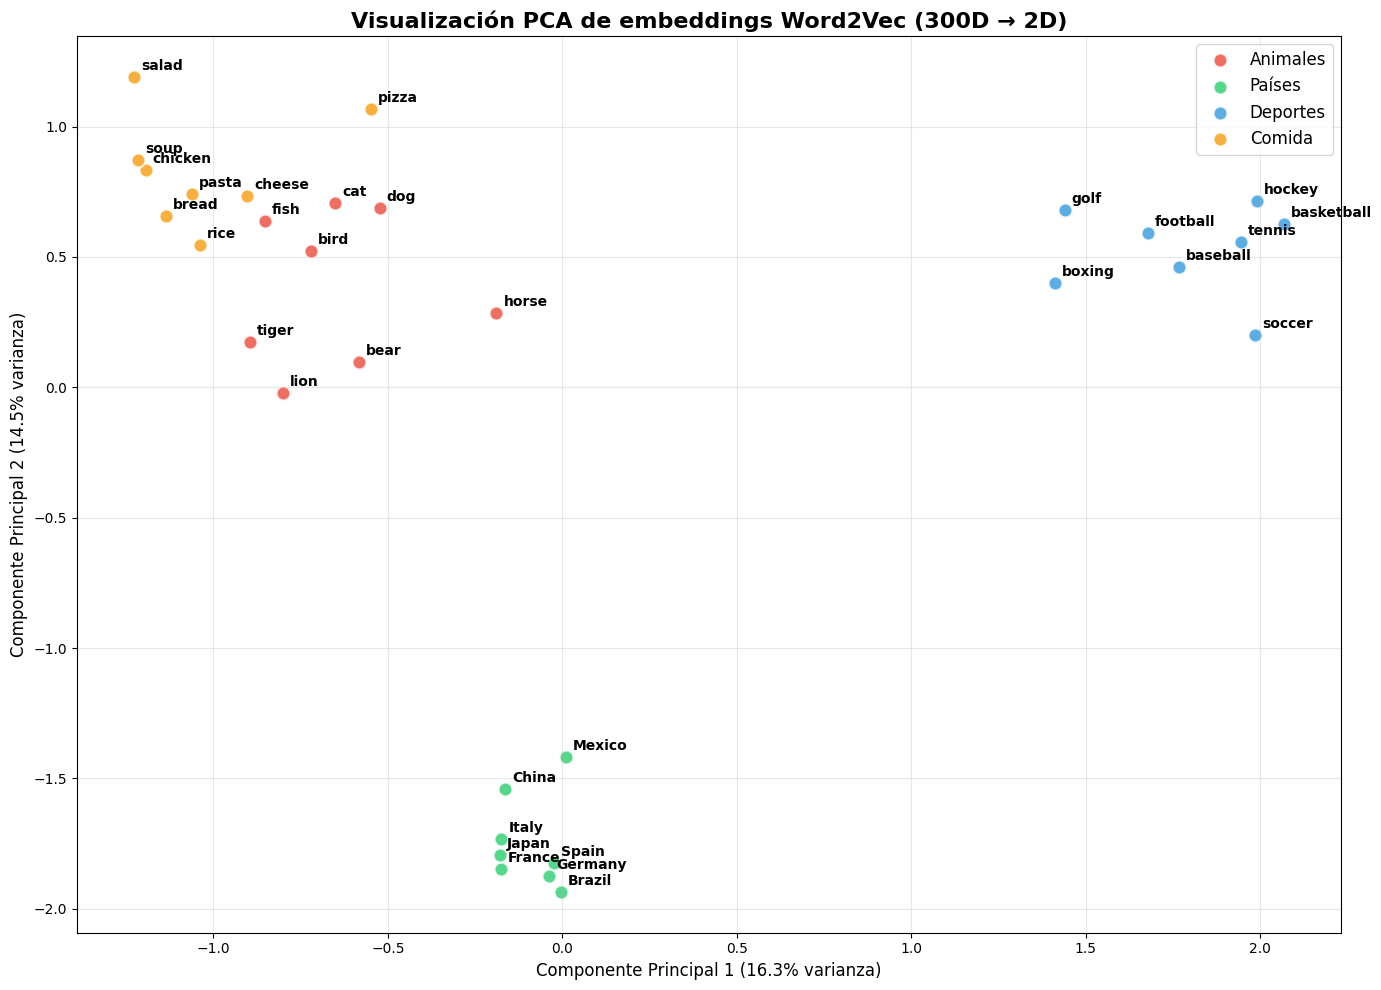


Varianza explicada por las 2 componentes: 30.8%


In [22]:
# --- EJEMPLO 5: Visualización de embeddings con PCA ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Definimos grupos de palabras por categorías
categorias = {
    'Animales': ['dog', 'cat', 'horse', 'fish', 'bird', 'lion', 'tiger', 'bear'],
    'Países':   ['Spain', 'France', 'Germany', 'Italy', 'Japan', 'China', 'Brazil', 'Mexico'],
    'Deportes':  ['football', 'basketball', 'tennis', 'baseball', 'soccer', 'hockey', 'golf', 'boxing'],
    'Comida':    ['pizza', 'pasta', 'rice', 'bread', 'cheese', 'chicken', 'salad', 'soup'],
}

colores = {'Animales': '#e74c3c', 'Países': '#2ecc71', 'Deportes': '#3498db', 'Comida': '#f39c12'}

# Recopilamos vectores y etiquetas
palabras = []
vectores = []
etiquetas_cat = []

for cat, lista in categorias.items():
    for palabra in lista:
        if palabra in wv:
            palabras.append(palabra)
            vectores.append(wv[palabra])
            etiquetas_cat.append(cat)

vectores = np.array(vectores)

# Aplicamos PCA para reducir de 300 a 2 dimensiones
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores)

# Gráfica
plt.figure(figsize=(14, 10))

for cat in categorias:
    indices = [i for i, c in enumerate(etiquetas_cat) if c == cat]
    x = vectores_2d[indices, 0]
    y = vectores_2d[indices, 1]
    plt.scatter(x, y, label=cat, color=colores[cat], s=100, alpha=0.8, edgecolors='white', linewidth=1.5)
    for i in indices:
        plt.annotate(palabras[i], (vectores_2d[i, 0], vectores_2d[i, 1]),
                     fontsize=10, fontweight='bold',
                     xytext=(5, 5), textcoords='offset points')

plt.title('Visualización PCA de embeddings Word2Vec (300D → 2D)', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada por las 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%")


# A pesar de que PCA con 2 componentes solo captura una fracción de la
# varianza total (normalmente ~5-15%), las categorías tienden a formar
# clusters visibles en el plano 2D. Esto confirma que Word2Vec organiza
# las palabras en regiones del espacio vectorial según su significado.
# Las palabras de la misma categoría (animales, países, etc.) aparecen
# agrupadas, lo que valida que la proximidad en el espacio de embeddings
# corresponde a proximidad semántica.

---
### Ejemplo 6: Visualización de analogías con vectores

Una de las propiedades más impresionantes de Word2Vec es que las relaciones semánticas se representan como **direcciones paralelas** en el espacio vectorial. Si la relación *hombre→mujer* es similar a la relación *rey→reina*, los vectores de desplazamiento deberían ser aproximadamente paralelos.

Visualizamos esto proyectando ambos pares con PCA.

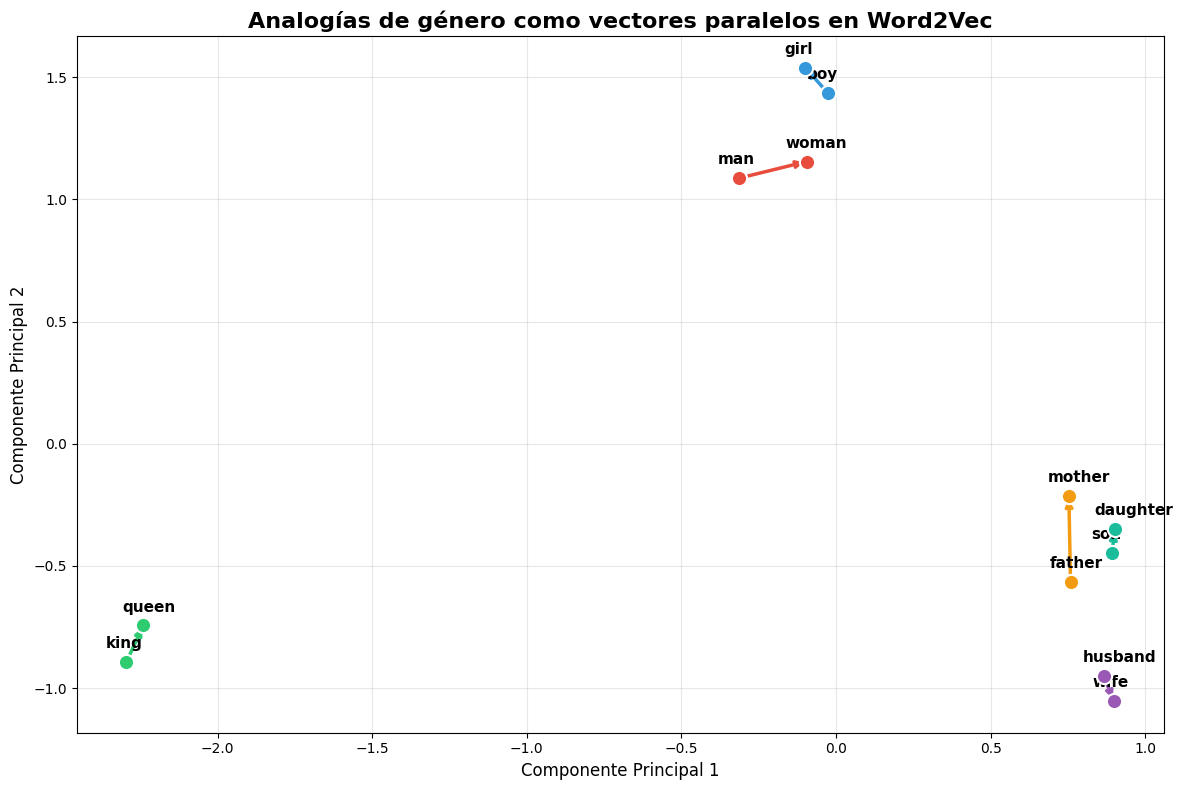

In [23]:
# --- EJEMPLO 6: Visualización de analogías como vectores paralelos ---

# Seleccionamos pares de analogías
pares_analogia = [
    ('man', 'woman'),
    ('king', 'queen'),
    ('boy', 'girl'),
    ('husband', 'wife'),
    ('father', 'mother'),
    ('son', 'daughter'),
]

# Extraemos vectores
todas_palabras = []
todos_vectores = []
for p1, p2 in pares_analogia:
    todas_palabras.extend([p1, p2])
    todos_vectores.extend([wv[p1], wv[p2]])

todos_vectores = np.array(todos_vectores)

# PCA a 2D
pca2 = PCA(n_components=2)
vecs_2d = pca2.fit_transform(todos_vectores)

# Gráfica con flechas entre cada par
plt.figure(figsize=(12, 8))

colores_pares = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

for i, (p1, p2) in enumerate(pares_analogia):
    idx1 = i * 2
    idx2 = i * 2 + 1
    x1, y1 = vecs_2d[idx1]
    x2, y2 = vecs_2d[idx2]

    # Dibujamos flecha del masculino al femenino
    plt.annotate('', xy=(x2, y2), xytext=(x1, y1),
                 arrowprops=dict(arrowstyle='->', color=colores_pares[i], lw=2.5))

    # Etiquetas
    plt.scatter([x1, x2], [y1, y2], color=colores_pares[i], s=120, zorder=5, edgecolors='white', linewidth=1.5)
    plt.annotate(p1, (x1, y1), fontsize=11, fontweight='bold', xytext=(-15, 10), textcoords='offset points')
    plt.annotate(p2, (x2, y2), fontsize=11, fontweight='bold', xytext=(-15, 10), textcoords='offset points')

plt.title('Analogías de género como vectores paralelos en Word2Vec', fontsize=16, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Si Word2Vec ha capturado bien la relación de género, las flechas
# deberían apuntar en direcciones similares (paralelas).
# Esto demuestra que la aritmética vectorial funciona porque
# la relación semántica se codifica como una dirección consistente
# en el espacio de alta dimensionalidad.
# man→woman ≈ king→queen ≈ boy→girl ≈ father→mother

---
### Resumen y conclusiones del análisis

**Sobre la práctica original:**
- El modelo `word2vec-google-news-300` codifica cada palabra en un vector de 300 dimensiones, entrenado sobre ~100 mil millones de palabras de noticias de Google.
- La **distancia coseno** es la métrica adecuada para comparar estos vectores: valores cercanos a 0 indican alta similitud semántica y valores cercanos a 1 indican baja similitud.
- La **aritmética vectorial** permite descubrir relaciones semánticas: `king - man + woman ≈ queen`.
- Los embeddings heredan los **sesgos** presentes en los datos de entrenamiento.

**Sobre los ejemplos propios:**
1. **Campos semánticos**: Las distancias coseno confirman que palabras del mismo dominio (animales, deportes, alimentos) son más cercanas entre sí que palabras de dominios distintos.
2. **Analogías variadas**: Word2Vec captura relaciones geográficas (país→capital), gramaticales (pasado→presente), comparativas y familiares de forma geométrica.
3. **Detección de intrusos**: El método `doesnt_match` valida que el modelo entiende categorías semánticas, identificando correctamente la palabra que no encaja en un grupo.
4. **Sesgos extendidos**: Los sesgos no se limitan al ejemplo original; se manifiestan en profesiones STEM, liderazgo, deporte y roles domésticos.
5. **Visualización PCA**: Aunque se pierde información al reducir de 300 a 2 dimensiones, las agrupaciones semánticas son visibles, confirmando la estructura del espacio de embeddings.
6. **Vectores paralelos**: Las analogías se representan como direcciones consistentes en el espacio vectorial, lo que explica por qué la aritmética de vectores funciona.